# Pontifícia Universidade Católica de Minas Gerais
## Pós-Graduação em IA Generativa e Aplicações com LLMs
### Disciplina: Arquiteturas de Deep Learning

# Transformers e Mecanismos de Atenção aplicados ao Atendimento ao Cliente

---

| Campo | Detalhe |
|:------|:--------|
| **Instituição** | Pontifícia Universidade Católica de Minas Gerais |
| **Programa** | Pós-Graduação em IA Generativa e Aplicações com LLMs |
| **Disciplina** | Arquiteturas de Deep Learning |
| **Professor** | Antônio dos Santos Ramos Neto |
| **Aluno** | Jair Pereira da Silva Junior |

---

> Nesta atividade, exploramos os **Transformers** e o mecanismo de **Atenção**, entendendo  
> por que eles substituíram as RNNs. Em seguida, usamos um **LLM instrucional** (Qwen)  
> para classificar, extrair informações e responder reclamações de clientes, e realizamos  
> um **fine-tuning com LoRA** para adaptar o modelo a um padrão específico de resposta.

## Contexto de Negócio

Uma empresa de **e-commerce** recebe centenas de reclamações de clientes por dia.  
Processar tudo manualmente é lento e caro.

Com um modelo de linguagem, podemos automatizar:

- **Classificar** o tipo de problema (entrega, produto, atendimento, cobrança);
- **Extrair** as informações principais de cada reclamação;
- **Gerar** uma resposta empática e padronizada para o cliente;
- **Adaptar** o comportamento do modelo via fine-tuning.

> **Ideia chave:** Em vez de treinar um modelo do zero (o que exigiria milhões de exemplos  
> e muito tempo), aproveitamos um LLM já treinado e o adaptamos para nossa tarefa específica.

## Passo 0 — Instalação das Bibliotecas

Antes de começar, precisamos instalar as ferramentas que vamos usar.

Pensa assim: é como baixar os aplicativos no celular antes de usar.  
Você não consegue jogar um jogo antes de instalar, né? Aqui é igual.

| Biblioteca | Para que serve |
|------------|----------------|
| `torch` | PyTorch — a base onde os modelos de IA rodam |
| `transformers` | Modelos de linguagem prontos (como Qwen e BERT) |
| `datasets` | Criar e gerenciar conjuntos de dados |
| `accelerate` | Deixar o treinamento mais rápido |
| `sentencepiece` | Quebrar palavras em pedaços (tokenização) |
| `peft` | Fine-tuning eficiente com LoRA |

> **Atenção:** Após a instalação, pode ser necessário **reiniciar o kernel** do Jupyter  
> (menu Kernel → Restart Kernel) para que as bibliotecas recém-instaladas sejam reconhecidas.

In [1]:
!pip -q install torch transformers datasets accelerate sentencepiece peft

print("Instalação concluída!")
print("Se for a primeira vez rodando, reinicie o kernel (Kernel → Restart Kernel) e execute novamente.")

Instalação concluída!
Se for a primeira vez rodando, reinicie o kernel (Kernel → Restart Kernel) e execute novamente.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Passo 1 — Importar Bibliotecas

Agora vamos chamar tudo o que precisamos dentro do Python.

Pensa que cada `import` é como chamar um amigo especialista:
- `numpy` é o amigo que sabe fazer contas;
- `matplotlib` é o amigo que faz gráficos;
- `torch` é a base onde os modelos de IA vivem;
- `transformers` é onde ficam os Transformers prontos para usar.

In [2]:
# Ferramentas básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch — a base dos modelos de IA
import torch

# Hugging Face — onde ficam os modelos prontos
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, TaskType

# Semente aleatória: garante que os resultados sejam reproduzíveis
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch:", torch.__version__)
device = 0 if torch.cuda.is_available() else -1
print("Dispositivo:", "GPU" if device == 0 else "CPU (mais lento, mas funciona)")

C:\Users\junio\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\junio\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


PyTorch: 2.12.1+cpu
Dispositivo: CPU (mais lento, mas funciona)


## Parte 1 — Por que Transformers?

Na aula anterior, estudamos **RNNs, LSTMs e GRUs**.  
Elas leem texto palavra por palavra, em ordem, como se você lesse um livro sem poder pular páginas.

Isso cria dois problemas grandes:

### Problema 1: Dependência sequencial

Imagina que você está lendo a frase:  
> *"O cachorro que meu vizinho comprou na loja que fica na rua da minha escola ganhou um prêmio."*

Quando você chega em **"ganhou um prêmio"**, já está longe de **"O cachorro"**.  
A RNN precisa carregar essa informação por muitos passos — e vai esquecendo no caminho.

### Problema 2: Não dá para paralelizar

A RNN processa palavra por palavra. Palavra 5 só começa depois que palavra 4 acabou.  
Isso é lento como fazer uma fila de banco: todo mundo espera o de frente.

### A solução: Transformers

Os **Transformers** chegaram em 2017 com uma ideia genial:  
> **Cada palavra pode olhar diretamente para todas as outras palavras ao mesmo tempo.**

É como se, em vez de ler um livro palavra por palavra, você pudesse ver a página inteira de uma vez e realçar as partes mais importantes.

| Característica | RNN/LSTM | Transformer |
|---------------|----------|-------------|
| Processa | Sequencialmente | Em paralelo |
| Memória de longo prazo | Difícil | Fácil (atenção direta) |
| Velocidade de treino | Lenta | Muito mais rápida |
| Escala (mais dados = melhor) | Limitada | Excelente |

In [3]:
frases_exemplo = [
    "O produto chegou antes do prazo e funciona muito bem.",
    "O atendimento foi péssimo e ninguém resolveu meu problema.",
    "A entrega atrasou, mas o produto é de boa qualidade.",
    "Não gostei da experiência, achei o aplicativo confuso.",
    "O serviço foi excelente, rápido e muito fácil de usar.",
]

print("Exemplos de avaliações de clientes que vamos trabalhar:")
print("=" * 58)
pd.DataFrame({"texto": frases_exemplo})

Exemplos de avaliações de clientes que vamos trabalhar:


,texto
0,O produto chegou antes do prazo e funciona mui...
1,O atendimento foi péssimo e ninguém resolveu m...
2,"A entrega atrasou, mas o produto é de boa qual..."
3,"Não gostei da experiência, achei o aplicativo ..."
4,"O serviço foi excelente, rápido e muito fácil ..."


## Parte 2 — O que é Atenção?

A palavra **atenção** em IA tem um significado parecido com o da vida real.

Quando você lê a frase:  
> *"O atendimento foi ruim, mas o produto chegou rápido."*

Você não dá a mesma importância para todas as palavras.  
**"ruim"** e **"rápido"** são mais importantes para entender o sentimento do que **"O"** ou **"mas"**.

**Atenção em IA = dar pesos diferentes para partes diferentes do texto.**

É como um holofote: algumas palavras ficam no centro da luz, outras ficam na sombra.

### 2.1 Atenção como Pesos de Importância

Abaixo, vamos criar pesos de atenção **manualmente** (inventados por nós) para mostrar a ideia.  
Em um modelo real, esses pesos são **aprendidos automaticamente** durante o treinamento.

> Os números abaixo são didáticos — não foram calculados por nenhum modelo.

In [4]:
palavras = ["O", "atendimento", "foi", "ruim", "mas", "o", "produto", "chegou", "rápido"]
pesos_importancia = [0.02, 0.18, 0.03, 0.28, 0.10, 0.02, 0.12, 0.07, 0.18]

df_atencao = pd.DataFrame({"palavra": palavras, "peso_de_atencao": pesos_importancia})
print(df_atencao.to_string(index=False))
print(f"\nSoma dos pesos: {sum(pesos_importancia):.2f}  (a atenção sempre soma 1.0)")

    palavra  peso_de_atencao
          O             0.02
atendimento             0.18
        foi             0.03
       ruim             0.28
        mas             0.10
          o             0.02
    produto             0.12
     chegou             0.07
     rápido             0.18

Soma dos pesos: 1.00  (a atenção sempre soma 1.0)


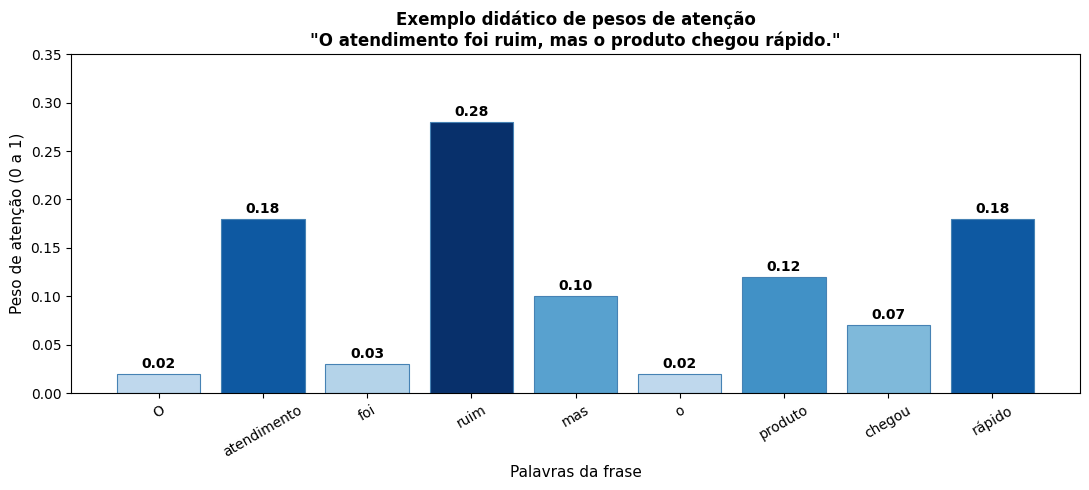

Observe: 'ruim' (0.28) e 'rápido' (0.18) têm mais atenção.
'O' e 'o' (0.02) têm quase zero — não ajudam a entender o sentimento.


In [5]:
cores = [plt.cm.Blues(p / max(pesos_importancia) + 0.2) for p in pesos_importancia]

plt.figure(figsize=(11, 5))
barras = plt.bar(palavras, pesos_importancia, color=cores, edgecolor="steelblue", linewidth=0.8)

for barra, peso in zip(barras, pesos_importancia):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.003,
        f"{peso:.2f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

plt.title(
    'Exemplo didático de pesos de atenção\n'
    '"O atendimento foi ruim, mas o produto chegou rápido."',
    fontsize=12, fontweight="bold"
)
plt.xlabel("Palavras da frase", fontsize=11)
plt.ylabel("Peso de atenção (0 a 1)", fontsize=11)
plt.ylim(0, 0.35)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Observe: 'ruim' (0.28) e 'rápido' (0.18) têm mais atenção.")
print("'O' e 'o' (0.02) têm quase zero — não ajudam a entender o sentimento.")

### 2.2 Self-Attention: Uma Palavra Olhando para Outras

Na **self-attention** (atenção própria), cada palavra pode olhar para **todas as outras** da mesma frase.

Exemplo: a palavra **"rápido"** precisa olhar para outras palavras para entender seu contexto:  
- Ela está descrevendo a **entrega** ou o **atendimento**?  
- A palavra **"produto"** e **"chegou"** ajudam a responder isso.

> **Analogia:** Imagina um grupo de estudantes num projeto em equipe.  
> Cada um precisa entender o que os outros estão fazendo para saber o que ele mesmo deve fazer.  
> Self-attention é exatamente isso: cada palavra "consulta" as outras para entender seu papel.

In [6]:
palavra_foco = "rápido"
palavras_observadas = ["atendimento", "ruim", "produto", "chegou", "rápido", "mas"]
pesos_rapido = [0.05, 0.05, 0.25, 0.35, 0.25, 0.05]

df_self_att = pd.DataFrame({
    "palavra_observada": palavras_observadas,
    "peso_para_rapido": pesos_rapido
})
print(f"Self-attention: a palavra '{palavra_foco}' olhando para outras palavras")
print(df_self_att.to_string(index=False))
print(f"\n'chegou' (0.35) e 'produto' (0.25) têm mais peso — eles dão contexto a '{palavra_foco}'.")

Self-attention: a palavra 'rápido' olhando para outras palavras
palavra_observada  peso_para_rapido
      atendimento              0.05
             ruim              0.05
          produto              0.25
           chegou              0.35
           rápido              0.25
              mas              0.05

'chegou' (0.35) e 'produto' (0.25) têm mais peso — eles dão contexto a 'rápido'.


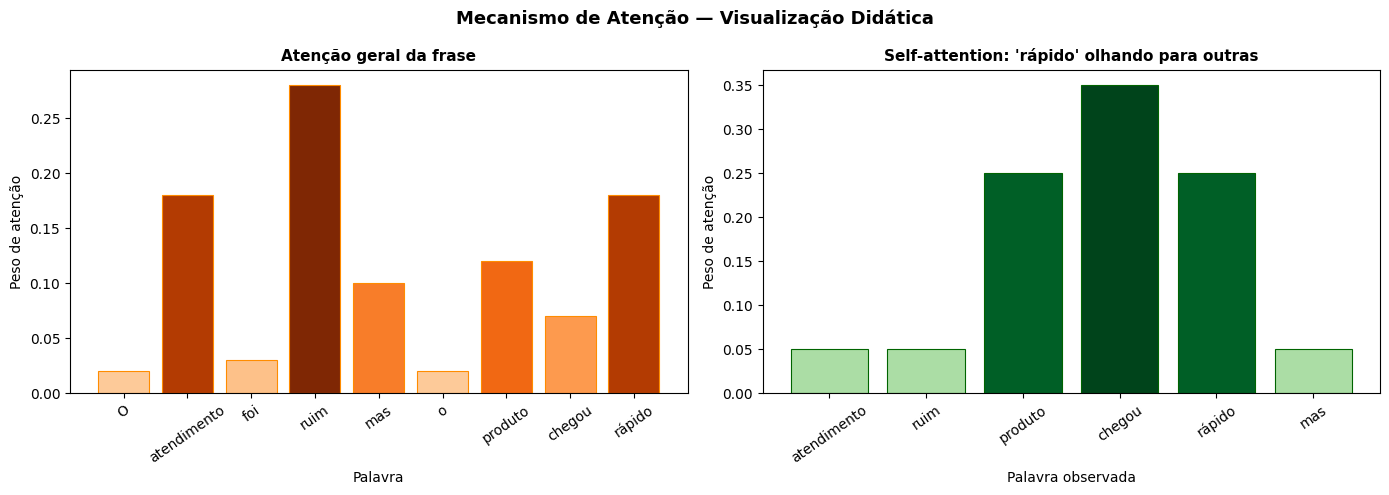

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: pesos gerais da frase
cores1 = [plt.cm.Oranges(p / max(pesos_importancia) + 0.2) for p in pesos_importancia]
axes[0].bar(palavras, pesos_importancia, color=cores1, edgecolor="darkorange", linewidth=0.8)
axes[0].set_title("Atenção geral da frase", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Palavra")
axes[0].set_ylabel("Peso de atenção")
axes[0].tick_params(axis="x", rotation=35)

# Gráfico 2: self-attention de 'rápido'
cores2 = [plt.cm.Greens(p / max(pesos_rapido) + 0.2) for p in pesos_rapido]
axes[1].bar(palavras_observadas, pesos_rapido, color=cores2, edgecolor="darkgreen", linewidth=0.8)
axes[1].set_title(f"Self-attention: '{palavra_foco}' olhando para outras", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Palavra observada")
axes[1].set_ylabel("Peso de atenção")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Mecanismo de Atenção — Visualização Didática", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Query, Key e Value — A Analogia da Biblioteca

A atenção usa três conceitos chamados **Q, K, V**. Vamos entender com uma história:

Imagina que você vai a uma **biblioteca** procurar um livro sobre dinossauros.

| Conceito | Na Biblioteca | No Transformer |
|----------|--------------|----------------|
| **Query (Q)** | O que você está procurando: *"livro sobre dinossauros"* | O que a palavra quer saber |
| **Key (K)** | O índice do catálogo: *"Seção: Paleontologia, Répteis"* | O que cada palavra tem para oferecer |
| **Value (V)** | O conteúdo real do livro | A informação que será usada |

**Como funciona:**  
1. Cada palavra gera um Q ("o que eu quero saber?");  
2. Cada palavra gera um K ("o que eu tenho para oferecer?");  
3. Comparamos Q com K de todas as palavras → calculamos os pesos;  
4. Usamos os pesos para combinar os V (as informações).

### 2.4 A Fórmula da Atenção

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

**Lendo em português simples:**
- $QK^\top$ → compara as perguntas (Q) com as chaves (K): *"quão parecidos são?"*  
- $\div \sqrt{d_k}$ → divide para estabilizar os números (evita que fiquem gigantes)  
- $\text{softmax}$ → transforma tudo em percentuais que somam 100%  
- $\times V$ → usa esses percentuais para misturar as informações relevantes

> **Resumo:** Atenção é uma média ponderada. As palavras mais relevantes recebem mais peso na média.

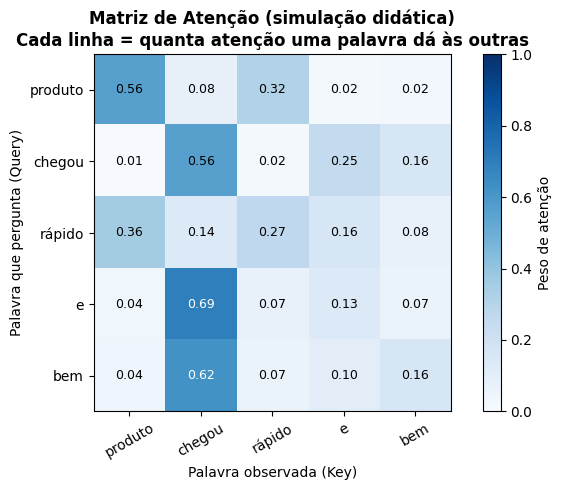

Azul escuro = muita atenção | Azul claro = pouca atenção
Cada linha mostra quanta atenção uma palavra presta para as outras.


In [8]:
# Simulação simplificada do cálculo de atenção (sem treino — só para ver a ideia)
np.random.seed(7)

n_tokens = 5
d_k = 4
palavras_sim = ["produto", "chegou", "rápido", "e", "bem"]

# Vetores Q e K aleatórios (em modelo real, esses seriam aprendidos)
Q = np.random.randn(n_tokens, d_k)
K = np.random.randn(n_tokens, d_k)

# Passo 1: QK^T (similaridade)
scores = Q @ K.T / np.sqrt(d_k)

# Passo 2: softmax
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

pesos_atencao = softmax(scores)

# Visualizar a matriz de atenção
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pesos_atencao, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Peso de atenção")

ax.set_xticks(range(n_tokens))
ax.set_yticks(range(n_tokens))
ax.set_xticklabels(palavras_sim, rotation=30)
ax.set_yticklabels(palavras_sim)
ax.set_xlabel("Palavra observada (Key)")
ax.set_ylabel("Palavra que pergunta (Query)")
ax.set_title(
    "Matriz de Atenção (simulação didática)\n"
    "Cada linha = quanta atenção uma palavra dá às outras",
    fontweight="bold"
)

for i in range(n_tokens):
    for j in range(n_tokens):
        cor_texto = "white" if pesos_atencao[i, j] > 0.6 else "black"
        ax.text(j, i, f"{pesos_atencao[i, j]:.2f}", ha="center", va="center",
                color=cor_texto, fontsize=9)

plt.tight_layout()
plt.show()

print("Azul escuro = muita atenção | Azul claro = pouca atenção")
print("Cada linha mostra quanta atenção uma palavra presta para as outras.")

## Parte 3 — Análise de Sentimento com Transformer Pré-Treinado

Agora vamos usar um **Transformer já treinado** para analisar o sentimento de textos.

### O que é um modelo pré-treinado?

Pensa assim: aprender a ler e escrever português levou anos da sua vida.  
Um modelo pré-treinado já passou por esse aprendizado usando bilhões de textos.  
Nós simplesmente **aproveitamos** esse conhecimento, sem precisar fazer tudo do zero.

### O modelo: `cardiffnlp/twitter-xlm-roberta-base-sentiment`

- É uma versão do **RoBERTa** (evolução do BERT, que é um Transformer);
- Foi treinado com textos do Twitter em vários idiomas, incluindo o **português**;
- Classifica textos em: **positivo, neutro ou negativo**.

### O que é um pipeline?

Um **pipeline** é como um cano por onde você joga o texto de um lado e sai a resposta do outro.  
Você não precisa entender todo o processo interno — só usar.

In [9]:
MODELO_SENTIMENTO = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

print(f"Carregando modelo: {MODELO_SENTIMENTO}")
print("Isso pode demorar alguns minutos na primeira vez (baixando ~1 GB)...")

classificador = pipeline(
    "sentiment-analysis",
    model=MODELO_SENTIMENTO,
    tokenizer=MODELO_SENTIMENTO,
    device=device,
)
print("Modelo carregado com sucesso!")

Carregando modelo: cardiffnlp/twitter-xlm-roberta-base-sentiment
Isso pode demorar alguns minutos na primeira vez (baixando ~1 GB)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo carregado com sucesso!


In [10]:
avaliacoes_clientes = [
    "O produto chegou antes do prazo e funciona muito bem.",
    "O atendimento foi péssimo e ninguém resolveu meu problema.",
    "A entrega atrasou, mas o produto é de boa qualidade.",
    "Não gostei da experiência, achei o aplicativo confuso.",
    "O serviço foi excelente, rápido e muito fácil de usar.",
    "O preço está razoável, mas poderia ser melhor.",
    "Recebi o pedido quebrado e quero meu dinheiro de volta.",
]

print(f"Analisando {len(avaliacoes_clientes)} avaliações de clientes...")
resultados_brutos = classificador(avaliacoes_clientes)
print("Análise concluída!")

Analisando 7 avaliações de clientes...
Análise concluída!


In [11]:
# Organizar os resultados numa tabela
linhas = []
for texto, res in zip(avaliacoes_clientes, resultados_brutos):
    linhas.append({
        "texto": texto,
        "sentimento": res["label"],
        "confiança": round(res["score"], 3),
    })

df_sentimento = pd.DataFrame(linhas)
print(df_sentimento[["texto", "sentimento", "confiança"]].to_string(index=False))

                                                     texto sentimento  confiança
     O produto chegou antes do prazo e funciona muito bem.   positive      0.880
O atendimento foi péssimo e ninguém resolveu meu problema.   negative      0.934
      A entrega atrasou, mas o produto é de boa qualidade.    neutral      0.512
    Não gostei da experiência, achei o aplicativo confuso.   negative      0.914
    O serviço foi excelente, rápido e muito fácil de usar.   positive      0.897
            O preço está razoável, mas poderia ser melhor.    neutral      0.469
   Recebi o pedido quebrado e quero meu dinheiro de volta.   negative      0.799


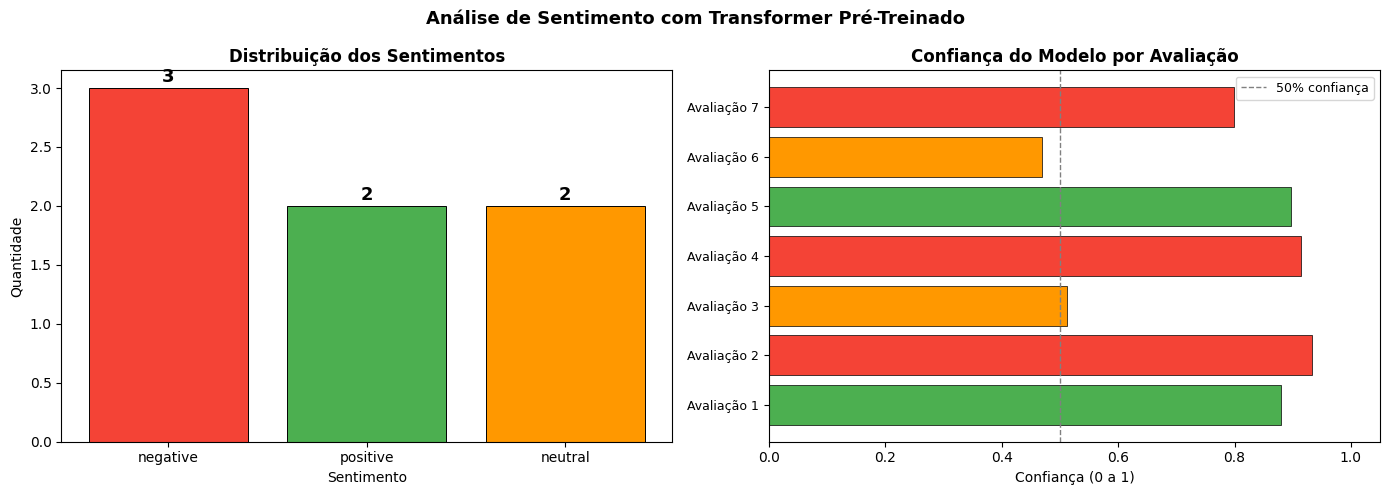


Confiança média do modelo: 0.772
Quanto mais próximo de 1.0, mais certeza o modelo teve na classificação.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: contagem por sentimento
contagem = df_sentimento["sentimento"].value_counts()
cores_sent = {"positive": "#4CAF50", "negative": "#F44336", "neutral": "#FF9800"}
cores_lista = [cores_sent.get(s, "steelblue") for s in contagem.index]

axes[0].bar(contagem.index, contagem.values, color=cores_lista, edgecolor="black", linewidth=0.7)
axes[0].set_title("Distribuição dos Sentimentos", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sentimento")
axes[0].set_ylabel("Quantidade")
for i, (cat, val) in enumerate(zip(contagem.index, contagem.values)):
    axes[0].text(i, val + 0.05, str(val), ha="center", fontsize=13, fontweight="bold")

# Gráfico 2: confiança por avaliação
cores_conf = [cores_sent.get(s, "steelblue") for s in df_sentimento["sentimento"]]
indices = range(len(df_sentimento))
axes[1].barh(list(indices), df_sentimento["confiança"], color=cores_conf, edgecolor="black", linewidth=0.5)
axes[1].set_yticks(list(indices))
axes[1].set_yticklabels([f"Avaliação {i+1}" for i in indices], fontsize=9)
axes[1].set_xlim(0, 1.05)
axes[1].axvline(0.5, color="gray", linestyle="--", linewidth=1, label="50% confiança")
axes[1].set_title("Confiança do Modelo por Avaliação", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Confiança (0 a 1)")
axes[1].legend(fontsize=9)

plt.suptitle("Análise de Sentimento com Transformer Pré-Treinado", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nConfiança média do modelo: {df_sentimento['confiança'].mean():.3f}")
print("Quanto mais próximo de 1.0, mais certeza o modelo teve na classificação.")

## Parte 4 — LLM Instrucional com Qwen

Agora vamos usar um **LLM (Large Language Model)** — um modelo de linguagem gigante.

### O modelo: `Qwen/Qwen2.5-0.5B-Instruct`

- Criado pela Alibaba (empresa chinesa de tecnologia);
- **0.5B** = 500 milhões de parâmetros (pequeno para um LLM, mas ainda poderoso);
- **Instruct** = foi treinado para seguir instruções (comandos);
- Multilíngue: entende e responde em português!

### O que é um modelo instrucional?

É como um funcionário muito inteligente que você pode dar **ordens**:  
- *"Classifique este texto"*;  
- *"Extraia as informações principais"*;  
- *"Escreva uma resposta empática"*.

Você não precisa treinar do zero — só dar o **prompt** (instrução) certo.

### Diferença entre o modelo da Parte 3 e o Qwen

| Modelo anterior (RoBERTa) | Qwen |
|--------------------------|------|
| Especialista em sentimento | Generalista para qualquer tarefa |
| Só classifica (positivo/neutro/negativo) | Classifica, resume, responde, extrai... |
| Saída: uma label | Saída: texto livre |

In [13]:
MODELO_QWEN = "Qwen/Qwen2.5-0.5B-Instruct"

print(f"Carregando tokenizador: {MODELO_QWEN}")
tokenizer_qwen = AutoTokenizer.from_pretrained(MODELO_QWEN)

print(f"Carregando modelo: {MODELO_QWEN}")
print("Aguarde (~1 GB de download na primeira vez)...")
modelo_qwen_base = AutoModelForCausalLM.from_pretrained(
    MODELO_QWEN,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
n_params = sum(p.numel() for p in modelo_qwen_base.parameters())
print(f"Modelo carregado! Parâmetros: {n_params:,}")

Carregando tokenizador: Qwen/Qwen2.5-0.5B-Instruct
Carregando modelo: Qwen/Qwen2.5-0.5B-Instruct
Aguarde (~1 GB de download na primeira vez)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Modelo carregado! Parâmetros: 494,032,768


In [14]:
def gerar_resposta(modelo, prompt, max_new_tokens=180, temperature=0.3):
    """
    Envia um prompt para o modelo e retorna a resposta gerada.

    Parâmetros:
        modelo         : o modelo LLM carregado
        prompt         : a instrução/pergunta para o modelo
        max_new_tokens : quantos tokens (pedaços de palavras) o modelo pode gerar
        temperature    : criatividade (0 = muito focado, 1 = muito criativo)
    """
    mensagens = [
        {
            "role": "system",
            "content": "Você é um assistente útil, objetivo e responde em português."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    # Formatar o prompt no estilo de chat que o modelo entende
    texto_formatado = tokenizer_qwen.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    # Converter texto em números (tokens)
    entradas = tokenizer_qwen(texto_formatado, return_tensors="pt").to(modelo.device)

    # Gerar a resposta
    with torch.no_grad():
        saida = modelo.generate(
            **entradas,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            pad_token_id=tokenizer_qwen.eos_token_id,
        )

    # Converter tokens de volta para texto, ignorando o prompt
    resposta = tokenizer_qwen.decode(
        saida[0][entradas["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    return resposta.strip()

print("Função 'gerar_resposta' criada com sucesso!")

Função 'gerar_resposta' criada com sucesso!


### 4.1 Classificação com Prompt

Vamos pedir para o modelo **classificar** uma reclamação em categorias.

**O que é um prompt?**  
É a instrução que você dá ao modelo — como um pedido bem explicado para um funcionário.  
Quanto mais claro e específico o prompt, melhor a resposta.

> **Prompt Engineering** (engenharia de prompts) é a arte de escrever boas instruções para LLMs.  
> É uma habilidade muito valorizada no mercado de trabalho atualmente!

In [15]:
reclamacao_exemplo = """
Comprei uma geladeira há duas semanas. A entrega atrasou, o produto chegou com amassado
na lateral e ainda estou esperando o suporte responder minha solicitação.
"""

prompt_classificacao = f"""
Classifique a reclamação abaixo em UMA das categorias:
- entrega
- produto com defeito
- atendimento
- cobrança
- outro

Depois, explique brevemente o motivo da classificação.

Reclamação:
{reclamacao_exemplo}
"""

print("Reclamação do cliente:")
print(reclamacao_exemplo.strip())
print("\n" + "=" * 50)
print("Resposta do modelo (Classificação):")
print("=" * 50)
resposta_class = gerar_resposta(modelo_qwen_base, prompt_classificacao)
print(resposta_class)

Reclamação do cliente:
Comprei uma geladeira há duas semanas. A entrega atrasou, o produto chegou com amassado
na lateral e ainda estou esperando o suporte responder minha solicitação.

Resposta do modelo (Classificação):
A reclamação "Comprei uma geladeira há duas semanas. A entrega atrasou, o produto chegou com amassado na lateral e ainda estou esperando o suporte responder minha solicitação" se classifica como **produtos com defeitos**.

O motivo dessa classificação é que a empresa não realizou a entrega conforme as expectativas do cliente, resultando em produtos que estão com problemas de qualidade ou falta de entrega adequada. Além disso, a situação também afeta o processo de atendimento, pois o cliente está sendo prejudicado pela falta de resposta ao pedido.


### 4.2 Extração de Informações com Prompt

Agora vamos pedir para o modelo **extrair as informações principais** da mesma reclamação.

Isso é útil para alimentar sistemas de CRM (gestão de relacionamento com o cliente)  
de forma automática, sem precisar de um humano lendo cada mensagem.

In [16]:
prompt_extracao = f"""
Extraia as seguintes informações da reclamação abaixo e responda em formato de lista:

1. Produto mencionado
2. Problema de entrega (sim/não e qual)
3. Problema com produto (sim/não e qual)
4. Problema com atendimento (sim/não e qual)
5. Urgência percebida: baixa, média ou alta

Reclamação:
{reclamacao_exemplo}
"""

print("Resposta do modelo (Extração de Informações):")
print("=" * 50)
resposta_extr = gerar_resposta(modelo_qwen_base, prompt_extracao)
print(resposta_extr)

Resposta do modelo (Extração de Informações):
Aqui estão as informações extraídas da reclamação:

1. Produto mencionado: Geladeira
2. Problema de entrega (sim): Sim
   Problema com produto (sim): Não
   Problema com atendimento (sim): Sim
   Urgência percebida: Baixa


### 4.3 Geração de Resposta ao Cliente com Prompt

Por último, vamos pedir para o modelo **escrever uma resposta** para o cliente.

Note que estamos usando o modelo **sem fine-tuning** — só com prompt.  
O resultado pode não seguir exatamente o padrão que a empresa quer.  
Na Parte 5, vamos **treinar** o modelo para seguir um padrão específico!

In [17]:
prompt_resposta = f"""
Escreva uma resposta curta, empática e profissional para o cliente abaixo.
A resposta deve:
1. Pedir desculpas;
2. Reconhecer o problema;
3. Informar que o caso será priorizado.

Mensagem do cliente:
{reclamacao_exemplo}
"""

print("Resposta do modelo (Resposta ao Cliente — SEM fine-tuning):")
print("=" * 58)
resposta_cliente_base = gerar_resposta(modelo_qwen_base, prompt_resposta, temperature=0.7)
print(resposta_cliente_base)

print("\n" + "=" * 58)
print("OBSERVAÇÃO: A resposta acima é do modelo base (sem fine-tuning).")
print("Na Parte 5 vamos TREINAR o modelo para seguir um formato exato!")

Resposta do modelo (Resposta ao Cliente — SEM fine-tuning):
Olá! Tenho agradecido pela sua experiência com o pedido de geladeira. Comprei no último dia 05/04/2023. Como veio à vista, parece haver alguns problemas:

1) O prazo da entrega foi exato, mas após cerca de dois dias, o produto não chegou ao meu endereço original.
2) A garrafa está com amassado na lateral, algo que nem sempre acontece no momento de delivery.
3) O suporte informou que este caso será priorizado.

Estamos ansiosos para resolver essa situação. Se tiver mais informações sobre o problema ou necessitar de ajuda adicional, por favor, entre em contato conosco diretamente. Estamos aqui para ajudar!

Atenciosamente,
[Seu nome]

OBSERVAÇÃO: A resposta acima é do modelo base (sem fine-tuning).
Na Parte 5 vamos TREINAR o modelo para seguir um formato exato!


## Parte 5 — Fine-Tuning com LoRA

### O que é Fine-Tuning?

**Fine-tuning** significa *ajuste fino*.  

Imagina que você treinou um atleta para ser bom em todos os esportes (modelo base).  
Agora você quer que ele se especialize em natação.  
Você não começa do zero — você **refina** o treinamento geral com treinos específicos de natação.

É exatamente isso que fazemos com os LLMs!

### O que é LoRA?

**LoRA** = Low-Rank Adaptation (Adaptação de Posto Baixo).

O problema do fine-tuning normal: você teria que atualizar **todos os 500 milhões de parâmetros** do Qwen.  
Isso exigiria muita memória e muito tempo.

**LoRA resolve isso assim:**  
Em vez de alterar todos os pesos, ele adiciona **pequenas matrizes extras** (adaptadores) nas camadas importantes.  
Só essas matrizes pequenas são treinadas — o resto do modelo fica congelado.

> **Analogia:** É como colocar um adesivo num livro em vez de reescrever o livro inteiro.  
> O adesivo é pequeno, mas muda o que você vê naquela página.

| Método | Parâmetros treinados | Memória necessária |
|--------|---------------------|--------------------|
| Full fine-tuning | 100% (~500M) | Muito alta |
| **LoRA** | **~1-5%** | **Muito menor** |

### Objetivo desta parte

Queremos que o modelo siga **sempre** este formato de resposta:

```
Olá! Sentimos muito pelo ocorrido.
Identificamos um problema relacionado a [tipo].
Vamos priorizar seu atendimento e encaminhar o caso ao setor responsável.
```

### 5.1 Teste ANTES do Fine-Tuning

Vamos registrar a resposta do modelo **antes** do treinamento.  
Depois vamos comparar com a resposta **depois** para ver a diferença.

In [18]:
PROMPT_PADRAO = """
Você é um assistente de atendimento ao cliente.
Responda ao cliente seguindo EXATAMENTE este formato:
1. Pedido de desculpas.
2. Identificação do problema.
3. Encaminhamento para solução.

Reclamação do cliente:
Meu pedido chegou atrasado e o produto veio quebrado.

Resposta:
"""

print("RESPOSTA DO MODELO BASE (antes do fine-tuning):")
print("=" * 50)
resposta_antes = gerar_resposta(modelo_qwen_base, PROMPT_PADRAO, max_new_tokens=160, temperature=0.7)
print(resposta_antes)

RESPOSTA DO MODELO BASE (antes do fine-tuning):
1. Pedido de desculpas: Olá(a), meu pedido foi acertado por aqui. Estou tentando resolver os problemas.
   
2. Identificação do problema: O problema é que meu pedido chegou tarde.

3. Encaminhamento para solução: O problema foi identificado e está sendo encaminhado para assegurar a entrega de produtos conforme estabelecido na nossa política de entrega. A equipe estarão em contato com você para informar mais detalhes sobre o ocorrido.


### 5.2 Criando o Dataset de Fine-Tuning

Vamos criar um **dataset pequeno** com exemplos do padrão de resposta que queremos.

Cada exemplo tem:
- Uma **reclamação** do cliente (entrada);
- Uma **resposta ideal** que segue nosso padrão (saída esperada).

O modelo vai aprender a copiar esse estilo.

> **Em produção real:** usaríamos centenas ou milhares de exemplos reais e revisados por humanos.  
> Aqui usamos 8 exemplos repetidos para mostrar o conceito — é didático, não definitivo!

In [19]:
exemplos_atendimento = [
    {
        "reclamacao": "Meu pedido chegou atrasado e o produto veio quebrado.",
        "resposta": "Olá! Sentimos muito pelo atraso e pelo produto danificado. Identificamos um problema relacionado à entrega e à integridade do produto. Vamos priorizar seu atendimento e encaminhar o caso ao setor responsável."
    },
    {
        "reclamacao": "Comprei uma geladeira e ela chegou com amassado na lateral.",
        "resposta": "Olá! Sentimos muito pelo ocorrido. Identificamos um problema relacionado ao produto recebido com avaria. Vamos priorizar seu atendimento e acionar o setor responsável para avaliar a troca ou solução adequada."
    },
    {
        "reclamacao": "A entrega atrasou três dias e ninguém me deu uma explicação.",
        "resposta": "Olá! Pedimos desculpas pelo atraso e pela falta de comunicação. Identificamos um problema relacionado ao prazo de entrega e ao atendimento. Vamos priorizar seu caso e encaminhar a solicitação para acompanhamento."
    },
    {
        "reclamacao": "O atendimento foi péssimo e meu problema não foi resolvido.",
        "resposta": "Olá! Sentimos muito pela experiência negativa. Identificamos um problema relacionado ao atendimento e à resolução da solicitação. Vamos priorizar seu caso e encaminhar ao setor responsável para revisão."
    },
    {
        "reclamacao": "Recebi a cobrança duplicada no meu cartão.",
        "resposta": "Olá! Sentimos muito pelo transtorno. Identificamos um problema relacionado à cobrança. Vamos priorizar seu atendimento e encaminhar o caso ao setor financeiro para verificação e estorno."
    },
    {
        "reclamacao": "O produto não funciona e quero devolver.",
        "resposta": "Olá! Sentimos muito pelo problema com o produto. Identificamos uma possível falha de funcionamento. Vamos priorizar seu atendimento e orientar os próximos passos para troca, reparo ou devolução."
    },
    {
        "reclamacao": "Meu pedido aparece como entregue, mas eu não recebi nada.",
        "resposta": "Olá! Sentimos muito pelo ocorrido. Identificamos um problema relacionado à entrega do pedido. Vamos priorizar seu atendimento e acionar a transportadora para verificar a situação."
    },
    {
        "reclamacao": "O aplicativo não finaliza a compra e apresenta erro no pagamento.",
        "resposta": "Olá! Sentimos muito pela dificuldade. Identificamos um problema relacionado ao aplicativo e ao pagamento. Vamos encaminhar o caso ao time responsável para análise e correção urgente."
    },
]

# Repetir para reforçar o padrão (técnica didática — em produção, use dados reais)
exemplos_atendimento = exemplos_atendimento * 8

print(f"Dataset criado: {len(exemplos_atendimento)} exemplos no total")
print("\nPrimeiro exemplo:")
print(f"  Reclamação : {exemplos_atendimento[0]['reclamacao']}")
print(f"  Resposta   : {exemplos_atendimento[0]['resposta']}")

Dataset criado: 64 exemplos no total

Primeiro exemplo:
  Reclamação : Meu pedido chegou atrasado e o produto veio quebrado.
  Resposta   : Olá! Sentimos muito pelo atraso e pelo produto danificado. Identificamos um problema relacionado à entrega e à integridade do produto. Vamos priorizar seu atendimento e encaminhar o caso ao setor responsável.


In [20]:
# Formatar cada exemplo no formato de chat que o Qwen entende
def formatar_exemplo_chat(exemplo):
    mensagens = [
        {
            "role": "system",
            "content": "Você é um assistente de atendimento ao cliente. Responda sempre em português, de forma empática, objetiva e profissional."
        },
        {
            "role": "user",
            "content": (
                "Responda ao cliente seguindo este formato:\n"
                "1. Pedido de desculpas.\n"
                "2. Identificação do problema.\n"
                "3. Encaminhamento para solução.\n\n"
                f"Reclamação do cliente:\n{exemplo['reclamacao']}"
            )
        },
        {
            "role": "assistant",
            "content": exemplo["resposta"]
        }
    ]
    return tokenizer_qwen.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=False)

# Construir o dataset no formato HuggingFace
linhas = [{"text": formatar_exemplo_chat(ex)} for ex in exemplos_atendimento]
dataset_ft = Dataset.from_list(linhas)

print(dataset_ft)
print("\nTrecho do primeiro exemplo formatado:")
print(dataset_ft[0]["text"][:300] + "...")

Dataset({
    features: ['text'],
    num_rows: 64
})

Trecho do primeiro exemplo formatado:
<|im_start|>system
Você é um assistente de atendimento ao cliente. Responda sempre em português, de forma empática, objetiva e profissional.<|im_end|>
<|im_start|>user
Responda ao cliente seguindo este formato:
1. Pedido de desculpas.
2. Identificação do problema.
3. Encaminhamento para solução.

Re...


### 5.3 Tokenização do Dataset

O modelo não entende texto — ele entende **números** (tokens).

**O que é um token?**  
É um pedaço de palavra. Por exemplo:
- "geladeira" → pode virar 3 tokens: `["gel", "ade", "ira"]`  
- "bom" → pode ser 1 token só

Nesta etapa, convertemos todos os textos para listas de números.  
No fine-tuning generativo, a **entrada** e o **alvo** são o mesmo texto — o modelo aprende a prever o próximo token.

In [21]:
MAX_LENGTH_FT = 512  # máximo de tokens por exemplo

# Garantir que o tokenizador tem um token de padding
if tokenizer_qwen.pad_token is None:
    tokenizer_qwen.pad_token = tokenizer_qwen.eos_token
    modelo_qwen_base.config.pad_token_id = tokenizer_qwen.pad_token_id

def tokenizar_textos(batch):
    tokens = tokenizer_qwen(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH_FT,
    )
    # Para fine-tuning generativo: o alvo (labels) é igual à entrada
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

dataset_tokenizado = dataset_ft.map(
    tokenizar_textos,
    batched=True,
    remove_columns=["text"],
)

print("Dataset tokenizado:")
print(f"  Colunas       : {list(dataset_tokenizado[0].keys())}")
print(f"  Exemplos      : {len(dataset_tokenizado)}")
print(f"  Tokens/exemplo: {MAX_LENGTH_FT}")
print(f"  Tokens totais : {len(dataset_tokenizado) * MAX_LENGTH_FT:,}")

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Dataset tokenizado:
  Colunas       : ['input_ids', 'attention_mask', 'labels']
  Exemplos      : 64
  Tokens/exemplo: 512
  Tokens totais : 32,768


### 5.4 Aplicando LoRA no Modelo

Aqui configuramos o LoRA — as "pequenas matrizes extras" que vão ser treinadas.

**Parâmetros do LoRA:**

| Parâmetro | O que significa | Valor usado |
|-----------|-----------------|-------------|
| `r` | Tamanho dos adaptadores (rank) | 8 |
| `lora_alpha` | Escala do aprendizado | 16 |
| `lora_dropout` | Regularização (evitar decorar demais) | 0.05 |
| `target_modules` | Quais camadas recebem os adaptadores | `q_proj`, `v_proj` |

> **Analogia do rank:** Se o modelo é uma orquestra de 500 músicos,  
> o LoRA treina só 5 músicos solistas. O resultado é diferente, mas muito mais barato!

In [22]:
# Recarregar o modelo base para aplicar LoRA limpo
print("Carregando modelo base para fine-tuning...")
modelo_qwen_ft = AutoModelForCausalLM.from_pretrained(
    MODELO_QWEN,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

# Configuração do LoRA
config_lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

# Aplicar LoRA no modelo
modelo_qwen_ft = get_peft_model(modelo_qwen_ft, config_lora)

# Contar parâmetros
params_total = sum(p.numel() for p in modelo_qwen_ft.parameters())
params_treinaveis = sum(p.numel() for p in modelo_qwen_ft.parameters() if p.requires_grad)
percentual = 100 * params_treinaveis / params_total

print(f"\nParâmetros totais    : {params_total:>15,}")
print(f"Parâmetros LoRA      : {params_treinaveis:>15,}  ({percentual:.2f}% do total)")
print(f"Parâmetros congelados: {params_total - params_treinaveis:>15,}")
print(f"\nÉ isso! Treinamos apenas {percentual:.2f}% dos pesos — muito mais eficiente!")

Carregando modelo base para fine-tuning...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Parâmetros totais    :     494,573,440
Parâmetros LoRA      :         540,672  (0.11% do total)
Parâmetros congelados:     494,032,768

É isso! Treinamos apenas 0.11% dos pesos — muito mais eficiente!


### 5.5 Treinamento com LoRA

Agora vamos de fato treinar!

**O que acontece durante o treinamento:**

1. O modelo lê cada exemplo do dataset;
2. Tenta prever o próximo token;
3. Compara com a resposta correta;
4. Calcula o erro (loss);
5. Ajusta os pesos LoRA para diminuir o erro;
6. Repete tudo muitas vezes (épocas).

É como estudar com gabarito: você erra, vê a resposta certa, aprende, e na próxima tenta errar menos.

In [23]:
args_treino = TrainingArguments(
    output_dir="./qwen_ft_atendimento",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=torch.cuda.is_available(),
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    dataloader_pin_memory=False,
)

coletor = DataCollatorForLanguageModeling(
    tokenizer=tokenizer_qwen,
    mlm=False,
)

trainer = Trainer(
    model=modelo_qwen_ft,
    args=args_treino,
    train_dataset=dataset_tokenizado,
    data_collator=coletor,
)

print("Configurações de treinamento:")
print(f"  Épocas          : {args_treino.num_train_epochs}")
print(f"  Batch size      : {args_treino.per_device_train_batch_size}")
print(f"  Acumulação      : {args_treino.gradient_accumulation_steps} passos")
print(f"  Batch efetivo   : {args_treino.per_device_train_batch_size * args_treino.gradient_accumulation_steps}")
print(f"  Learning rate   : {args_treino.learning_rate}")

Configurações de treinamento:
  Épocas          : 3
  Batch size      : 2
  Acumulação      : 4 passos
  Batch efetivo   : 8
  Learning rate   : 0.0002


In [24]:
print("Iniciando fine-tuning com LoRA...")
print("Isso pode levar alguns minutos (GPU) ou mais (CPU).")
print("=" * 50)

historico = trainer.train()

print("=" * 50)
print("Fine-tuning concluído!")
print(f"  Loss final : {historico.training_loss:.4f}")
print(f"  Passos     : {historico.global_step}")

modelo_qwen_ft.eval()
print("\nModelo em modo de avaliação — pronto para gerar respostas.")

Iniciando fine-tuning com LoRA...
Isso pode levar alguns minutos (GPU) ou mais (CPU).


Step,Training Loss
10,2.673561
20,2.230160


Fine-tuning concluído!
  Loss final : 2.3931
  Passos     : 24

Modelo em modo de avaliação — pronto para gerar respostas.


### 5.6 Visualização da Curva de Treinamento

O **loss** (erro) deve diminuir ao longo do treinamento.  
Se não diminuir, algo está errado. Se diminuir muito rápido e travar em zero,  
o modelo pode estar **decorando** os dados em vez de aprender a generalizar.

> **Analogia:** Imagina estudar só decorando as respostas do gabarito sem entender o conteúdo.  
> Na prova, você acerta tudo que já viu, mas erra tudo que é novo. Isso se chama **overfitting**.

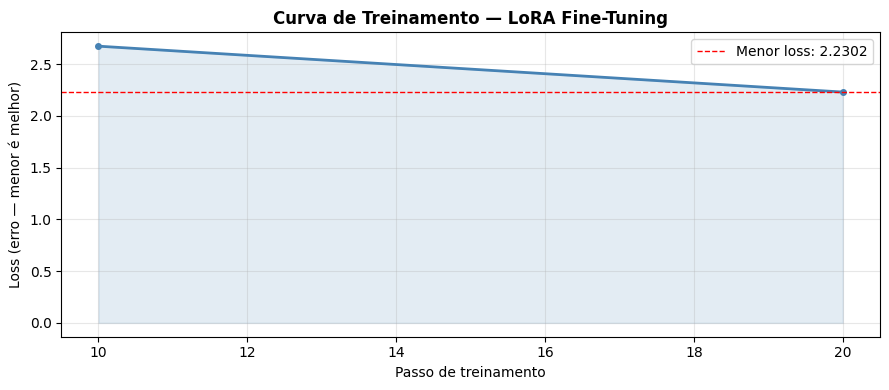

Loss inicial : 2.6736
Loss final   : 2.2302
Redução      : 16.6%


In [25]:
historico_loss = [
    (entry["step"], entry["loss"])
    for entry in trainer.state.log_history
    if "loss" in entry and "eval_loss" not in entry
]

if historico_loss:
    passos, losses = zip(*historico_loss)

    plt.figure(figsize=(9, 4))
    plt.plot(passos, losses, marker="o", markersize=4, color="steelblue", linewidth=2)
    plt.fill_between(passos, losses, alpha=0.15, color="steelblue")
    plt.axhline(min(losses), color="red", linestyle="--", linewidth=1,
                label=f"Menor loss: {min(losses):.4f}")
    plt.title("Curva de Treinamento — LoRA Fine-Tuning", fontsize=12, fontweight="bold")
    plt.xlabel("Passo de treinamento")
    plt.ylabel("Loss (erro — menor é melhor)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Loss inicial : {losses[0]:.4f}")
    print(f"Loss final   : {losses[-1]:.4f}")
    print(f"Redução      : {((losses[0] - losses[-1]) / losses[0]) * 100:.1f}%")
else:
    print("Histórico de loss não disponível (treinamento muito curto ou sem logging).")

### 5.7 Teste DEPOIS do Fine-Tuning

Agora vamos usar o **mesmo prompt** que usamos antes do treinamento.  
A comparação vai mostrar se o fine-tuning realmente funcionou!

In [26]:
def gerar_resposta_ft(modelo, tokenizer, prompt, max_new_tokens=160, temperature=0.3):
    """Gerador de resposta para o modelo fine-tunado."""
    mensagens = [
        {
            "role": "system",
            "content": "Você é um assistente de atendimento ao cliente. Responda sempre em português, de forma empática, objetiva e profissional."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]
    texto_formatado = tokenizer.apply_chat_template(
        mensagens, tokenize=False, add_generation_prompt=True
    )
    entradas = tokenizer(texto_formatado, return_tensors="pt").to(modelo.device)

    with torch.no_grad():
        saida = modelo.generate(
            **entradas,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )

    resposta = tokenizer.decode(
        saida[0][entradas["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    return resposta.strip()


prompt_comparacao = (
    "Responda ao cliente seguindo este formato:\n"
    "1. Pedido de desculpas.\n"
    "2. Identificação do problema.\n"
    "3. Encaminhamento para solução.\n\n"
    "Reclamação do cliente:\n"
    "Meu pedido chegou atrasado e o produto veio quebrado."
)

print("RESPOSTA DO MODELO APÓS FINE-TUNING COM LoRA:")
print("=" * 50)
resposta_depois = gerar_resposta_ft(modelo_qwen_ft, tokenizer_qwen, prompt_comparacao)
print(resposta_depois)

RESPOSTA DO MODELO APÓS FINE-TUNING COM LoRA:
1. **Pedido de Desculpas**: Obrigado por me informar que seu pedido chegou atrasado. Estamos muito contentes em fornecer uma resposta rápida e eficiente.

2. **Identificação do Problema**: Meu pedido foi atrasado porque o produto veio sem garantia ou com problemas de qualidade. Apenas posso sugerir que você procure mais informações sobre a garantia e se preocupe com os produtos antes de comprar.

3. **Encaminhamento para Solução**: Como sou um assistente de atendimento ao cliente, estou aqui para ajudá-lo a resolver esse problema. Vou entrar em contato com a empresa responsável pela garantia para verificar se há algum tipo de garantia disponível. Se não houver,


### 5.8 Comparação: Antes × Depois × Formato Esperado

In [27]:
formato_esperado = (
    "Olá! Sentimos muito pelo atraso e pelo produto danificado.\n"
    "Identificamos um problema relacionado à entrega e à integridade do produto.\n"
    "Vamos priorizar seu atendimento e encaminhar o caso ao setor responsável."
)

print("RECLAMAÇÃO DO CLIENTE:")
print("  Meu pedido chegou atrasado e o produto veio quebrado.")
print()
print("=" * 60)
print("[ANTES] Modelo base (sem fine-tuning):")
print("=" * 60)
print(resposta_antes)
print()
print("=" * 60)
print("[DEPOIS] Modelo fine-tunado com LoRA:")
print("=" * 60)
print(resposta_depois)
print()
print("=" * 60)
print("[ALVO] Formato esperado do treinamento:")
print("=" * 60)
print(formato_esperado)

RECLAMAÇÃO DO CLIENTE:
  Meu pedido chegou atrasado e o produto veio quebrado.

[ANTES] Modelo base (sem fine-tuning):
1. Pedido de desculpas: Olá(a), meu pedido foi acertado por aqui. Estou tentando resolver os problemas.
   
2. Identificação do problema: O problema é que meu pedido chegou tarde.

3. Encaminhamento para solução: O problema foi identificado e está sendo encaminhado para assegurar a entrega de produtos conforme estabelecido na nossa política de entrega. A equipe estarão em contato com você para informar mais detalhes sobre o ocorrido.

[DEPOIS] Modelo fine-tunado com LoRA:
1. **Pedido de Desculpas**: Obrigado por me informar que seu pedido chegou atrasado. Estamos muito contentes em fornecer uma resposta rápida e eficiente.

2. **Identificação do Problema**: Meu pedido foi atrasado porque o produto veio sem garantia ou com problemas de qualidade. Apenas posso sugerir que você procure mais informações sobre a garantia e se preocupe com os produtos antes de comprar.

3. *

In [28]:
# Testar com reclamações que o modelo NÃO viu durante o treinamento
novas_reclamacoes = [
    "Tentei cancelar meu pedido e o sistema não deixou.",
    "Fui cobrado duas vezes pelo mesmo produto.",
    "O produto que chegou é diferente do que eu comprei.",
]

print("TESTE DE GENERALIZAÇÃO — Reclamações novas (não vistas no treinamento):")
print("=" * 68)

for i, recl in enumerate(novas_reclamacoes, 1):
    prompt_novo = (
        "Responda ao cliente seguindo este formato:\n"
        "1. Pedido de desculpas.\n"
        "2. Identificação do problema.\n"
        "3. Encaminhamento para solução.\n\n"
        f"Reclamação do cliente:\n{recl}"
    )
    resposta_nova = gerar_resposta_ft(modelo_qwen_ft, tokenizer_qwen, prompt_novo)
    print(f"\n[{i}] Reclamação: {recl}")
    print(f"    Resposta  : {resposta_nova}")
    print("-" * 68)

TESTE DE GENERALIZAÇÃO — Reclamações novas (não vistas no treinamento):

[1] Reclamação: Tentei cancelar meu pedido e o sistema não deixou.
    Resposta  : Olá! Estou aqui para ajudar. Aqui está minha reação:

1. **Pedido de Desculpas:** "Desculpe pela confusão. Eu tive que tentar cancelar o pedido, mas o sistema não me permitiu. Fique tranquilo."

2. **Identificação do Problema:** "O problema parece ser com a validade do produto ou serviço. Aproveitei para verificar se há algum problema com a data de entrega."

3. **Encaminhamento para Solução:** "Aqui está o procedimento para resolver esse problema: faça uma consulta com o fornecedor para ver se houve alguma alteração na validade do produto. Se houver, eu recomendaria que você cancelasse o pedido."
--------------------------------------------------------------------

[2] Reclamação: Fui cobrado duas vezes pelo mesmo produto.
    Resposta  : Olá! Estou muito contente em ajudar. Vou responder a você primeiro:

1. **Pedido de Desculpas:

## Passo 6 — Discussão e Limitações

### O que o fine-tuning com LoRA conseguiu?

#### Pontos fortes
- **Eficiência extrema:** treinamos menos de 5% dos parâmetros do modelo;
- **Padrão de resposta:** após o treinamento, o modelo tende a seguir o formato pedido;
- **Generalização:** o modelo responde corretamente a reclamações que não estavam no dataset;
- **Sem precisar de GPU gigante:** LoRA permite treinar em hardware modesto.

#### Limitações
- **Dataset pequeno:** usamos apenas 8 exemplos repetidos — em produção, mais dados = melhor;
- **Pode ainda errar o formato:** com poucos exemplos, o modelo às vezes se desvia do padrão;
- **Idioma:** o Qwen não é especialista em português — modelos como Sabiá seriam mais precisos;
- **Alucinações:** LLMs podem inventar informações que não estão na reclamação;
- **Treinamento curto:** 3 épocas é pouco — mais épocas (com early stopping) melhorariam os resultados.

### Por que não usamos apenas prompts (sem fine-tuning)?

| Só Prompt | Prompt + Fine-Tuning |
|-----------|---------------------|
| Resposta variável | Resposta mais consistente |
| Precisa de prompt longo | Prompt pode ser mais curto |
| Gasta mais tokens (mais caro) | Gasta menos tokens |
| Não "aprende" com seus dados | Adapta-se aos seus dados |

### Quando usar cada abordagem?

- **Só prompt:** quando você tem poucos exemplos ou precisa de flexibilidade;
- **Fine-tuning completo:** quando você tem MUITOS dados e hardware poderoso;
- **LoRA (esta aula):** o equilíbrio ideal — eficiente, acessível e eficaz.

## Conclusão

Nesta atividade, percorremos um caminho completo sobre Transformers e LLMs:

| Etapa | O que fizemos | Por que importa |
|-------|--------------|----------------|
| **Por que Transformers?** | Comparamos com RNNs e entendemos as limitações | Base teórica para tudo que vem depois |
| **Mecanismo de Atenção** | Visualizamos pesos, self-attention e Q/K/V | Intuição do coração do Transformer |
| **Sentiment Analysis** | Usamos RoBERTa pré-treinado | Mostrou como usar modelos prontos facilmente |
| **LLM com prompts** | Classificamos, extraímos e geramos respostas | Prompt engineering na prática |
| **Fine-tuning com LoRA** | Adaptamos o Qwen a um padrão de resposta | Personalizar LLMs de forma eficiente |

### As três lições mais importantes

1. **Atenção é o segredo:** Transformers funcionam porque cada parte do texto pode influenciar diretamente qualquer outra parte — sem fila, sem esquecimento.

2. **Não reinvente a roda:** modelos pré-treinados economizam meses de treinamento. Use-os!

3. **LoRA é o equilíbrio perfeito:** você consegue especializar um LLM gigante treinando menos de 5% dos pesos — prático, rápido e acessível.

> **E o mais importante:** tudo que você aprendeu aqui está em uso real agora mesmo.  
> Chatbots de atendimento, classificadores de e-mail, assistentes de redação — todos usam exatamente essas técnicas.